# Ablation tests vs. the seed ruler

Compares 5 single-sim ablations against `utils/seed_ruler_table.ipynb`'s ruler (mean ± std of RMSE_WD / CSI@0.05 / CSI@0.30 across 5 seeds of `config_best_sweep.yaml`), that ruler is the natural seed-to-seed noise band.

| ablation | config | what changed vs. the ruler |
|---|---|---|
| nonweighted_rmse | `config_best_sweep_nonweighted_rmse.yaml` | `shallow_weight: 1.0` (ruler uses `5`) |
| conservation01 | `config_best_sweep_conservation01.yaml` | `conservation: 0.01` (ruler uses `0`) |
| coldstart | `config_best_sweep_coldstart.yaml` | trained/tested on the cold-start (`cutpolygon`) simulation instead of warm-start |
| hid64_scratch | `config_best_sweep_hid64_scratch.yaml` | `hid_features: 64` (ruler uses `32`), trained from scratch |
| hid64_finetune_dk15 | `config_best_sweep_hid64_finetune_dk15.yaml` | same architecture as hid64_scratch, but initialized from `results/finetuned_dk15.h5` instead of random init |


In [2]:
import os, sys

# Resolve the repo root robustly (works in VS Code and nbconvert, any start cwd)
try:
    REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(__vsc_ipynb_file__), '..'))
except NameError:
    _here = os.getcwd()
    REPO_ROOT = _here if os.path.isdir(os.path.join(_here, 'database')) \
                else os.path.abspath(os.path.join(_here, '..'))
assert os.path.isdir(os.path.join(REPO_ROOT, 'database')), f'Not the repo root: {REPO_ROOT}'
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import torch
import wandb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from utils.load import read_config
from utils.miscellaneous import get_model, fix_dict_in_config
from utils.dataset import create_model_dataset, get_temporal_test_dataset_parameters, to_temporal_dataset
from utils.visualization import PlotRollout
from training.train import LightningTrainer

torch.backends.cudnn.deterministic = True
torch.set_float32_matmul_precision('high')
print('Repo root:', REPO_ROOT)

Repo root: c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg


## 1. The ruler: loaded from `results/seed_table.csv`

In [3]:
seed_df = pd.read_csv('results/seed_table.csv')

RULER = {}  # ckpt_label -> {metric: (mean, std)}
for label in ['best_val_loss', 'best_CSI']:
    sub = seed_df[seed_df.ckpt == label]
    RULER[label] = {
        metric: (sub[metric].mean(), sub[metric].std(ddof=1))
        for metric in ['RMSE_WD', 'CSI_005', 'CSI_03']
    }

for label, metrics in RULER.items():
    print(f'--- ruler ({label}, n={ (seed_df.ckpt==label).sum() }) ---')
    for metric, (mean, std) in metrics.items():
        print(f'  {metric:8s}: {mean:.4f} ± {std:.4f}')

--- ruler (best_val_loss, n=5) ---
  RMSE_WD : 0.1422 ± 0.0101
  CSI_005 : 0.7032 ± 0.0286
  CSI_03  : 0.8321 ± 0.0164
--- ruler (best_CSI, n=5) ---
  RMSE_WD : 0.1690 ± 0.0217
  CSI_005 : 0.7609 ± 0.0419
  CSI_03  : 0.7717 ± 0.0482


## 2. Ablation checkpoints

In [4]:
ABLATIONS = [
    {'name': 'nonweighted_rmse',     'config': 'config_best_sweep_nonweighted_rmse.yaml',
     'checkpoint': 'results/best_sweep_nonweighted_rmse.h5',
     'checkpoint_csi': 'results/best_sweep_nonweighted_rmse_bestCSI.h5',
     'note': 'shallow_weight=1.0 (ruler=5)', 'comparable_to_ruler': True},
    {'name': 'conservation01',       'config': 'config_best_sweep_conservation01.yaml',
     'checkpoint': 'results/best_sweep_conservation01.h5',
     'checkpoint_csi': 'results/best_sweep_conservation01_bestCSI.h5',
     'note': 'conservation=0.01 (ruler=0)', 'comparable_to_ruler': True},
    {'name': 'coldstart',            'config': 'config_best_sweep_coldstart.yaml',
     'checkpoint': 'results/best_sweep_coldstart.h5',
     'checkpoint_csi': 'results/best_sweep_coldstart_bestCSI.h5',
     'note': 'cold-start (cutpolygon) dataset, not warmstart - different test set',
     'comparable_to_ruler': False},
    {'name': 'hid64_scratch',        'config': 'config_best_sweep_hid64_scratch.yaml',
     'checkpoint': 'results/best_sweep_hid64_scratch.h5',
     'checkpoint_csi': 'results/best_sweep_hid64_scratch_bestCSI.h5',
     'note': 'hid_features=64 (ruler=32), random init', 'comparable_to_ruler': True},
    {'name': 'hid64_finetune_dk15',  'config': 'config_best_sweep_hid64_finetune_dk15.yaml',
     'checkpoint': 'results/best_sweep_hid64_finetune_dk15.h5',
     'checkpoint_csi': 'results/best_sweep_hid64_finetune_dk15_bestCSI.h5',
     'note': 'hid_features=64, initialized from finetuned_dk15.h5', 'comparable_to_ruler': True},
]

print('--- checkpoint status ---')
for a in ABLATIONS:
    for key in ['checkpoint', 'checkpoint_csi']:
        exists = os.path.exists(a[key])
        print(f"{a['name']:<22} {key:<15} exists={exists!s:<6} {a[key]}")

--- checkpoint status ---
nonweighted_rmse       checkpoint      exists=True   results/best_sweep_nonweighted_rmse.h5
nonweighted_rmse       checkpoint_csi  exists=True   results/best_sweep_nonweighted_rmse_bestCSI.h5
conservation01         checkpoint      exists=True   results/best_sweep_conservation01.h5
conservation01         checkpoint_csi  exists=True   results/best_sweep_conservation01_bestCSI.h5
coldstart              checkpoint      exists=True   results/best_sweep_coldstart.h5
coldstart              checkpoint_csi  exists=True   results/best_sweep_coldstart_bestCSI.h5
hid64_scratch          checkpoint      exists=True   results/best_sweep_hid64_scratch.h5
hid64_scratch          checkpoint_csi  exists=True   results/best_sweep_hid64_scratch_bestCSI.h5
hid64_finetune_dk15    checkpoint      exists=True   results/best_sweep_hid64_finetune_dk15.h5
hid64_finetune_dk15    checkpoint_csi  exists=True   results/best_sweep_hid64_finetune_dk15_bestCSI.h5


## 3. Helper: load a checkpoint with architecture auto-detected from its own weights

In [5]:
def load_model_from_checkpoint(checkpoint_path, base_config, num_node_features, num_edge_features, previous_t, num_scales, device):
    ckpt = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    sd = ckpt['state_dict']
    hid = sd['model.edge_encoder.0.weight'].shape[0]

    proc_ids = sorted(set(
        int(k.split('.')[2]) for k in sd
        if k.startswith('model.gnn_processor.') and 'filter_matrix.' in k
    ))
    K_list = [
        sum(1 for k in sd if f'model.gnn_processor.{i}.filter_matrix.' in k and k.endswith('.weight')) - 1
        for i in proc_ids
    ]

    model_parameters = dict(base_config['models'])
    model_parameters.pop('model_type')
    model_parameters['hid_features'] = hid
    model_parameters['K'] = K_list
    model_parameters['num_scales'] = num_scales

    model = get_model('MSGNN')(
        num_node_features=num_node_features, num_edge_features=num_edge_features,
        previous_t=previous_t, device=device, **model_parameters,
    ).to(device)

    plmodule_kwargs = {
        'model': model,
        'lr_info': base_config['lr_info'],
        'trainer_options': base_config['trainer_options'],
        'temporal_test_dataset_parameters': get_temporal_test_dataset_parameters(base_config, base_config['temporal_dataset_parameters']),
    }
    plmodule = LightningTrainer.load_from_checkpoint(checkpoint_path, map_location=device, **plmodule_kwargs)
    model = plmodule.model.to(device)
    model.eval()
    return model, hid, K_list


def evaluate_checkpoint(ckpt_path, config_path, dataset_cache, epoch_from_ckpt=True):
    '''Evaluate one checkpoint against its own config's test dataset. Returns a dict of metrics, or None if missing.'''
    if not os.path.exists(ckpt_path):
        return None

    if config_path not in dataset_cache:
        cfg = read_config(config_path)
        wandb.init(mode='disabled', project='mswe-gnn', config=cfg, reinit=True)
        fix_dict_in_config(wandb)
        config = wandb.config

        _, _, test_dataset, scalers = create_model_dataset(
            scalers=config.scalers, device='cpu',
            **config.dataset_parameters,
            **config.selected_node_features,
            **config.selected_edge_features,
        )
        temporal_test_dataset_parameters = get_temporal_test_dataset_parameters(
            config, config.temporal_dataset_parameters
        )
        temporal_test_dataset = to_temporal_dataset(test_dataset, rollout_steps=-1, **temporal_test_dataset_parameters)
        num_node_features = temporal_test_dataset[0].x.size(-1)
        num_edge_features = temporal_test_dataset[0].edge_attr.size(-1)
        dataset_cache[config_path] = (
            dict(cfg), test_dataset, scalers, temporal_test_dataset_parameters,
            num_node_features, num_edge_features,
        )

    (cfg, test_dataset, scalers, temporal_test_dataset_parameters,
     num_node_features, num_edge_features) = dataset_cache[config_path]

    model, hid, K_list = load_model_from_checkpoint(
        ckpt_path, cfg,
        num_node_features=num_node_features, num_edge_features=num_edge_features,
        previous_t=temporal_test_dataset_parameters['previous_t'],
        num_scales=test_dataset[0].mesh.num_meshes, device='cpu',
    )

    plot_rollout = PlotRollout(
        model, test_dataset[0], scalers=scalers,
        warmup_steps=0, **temporal_test_dataset_parameters,
    )
    rollout_loss = plot_rollout._get_rollout_loss(type_loss='RMSE')
    loss_mean = rollout_loss.mean(0)
    rmse_wd = loss_mean[0].item() if loss_mean.ndim > 0 else loss_mean.item()
    csi_005 = plot_rollout._get_CSI(water_threshold=0.05).nanmean().item()
    csi_03 = plot_rollout._get_CSI(water_threshold=0.30).nanmean().item()

    epoch = None
    if epoch_from_ckpt:
        ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
        epoch = ckpt.get('epoch', None)

    return {'epoch': epoch, 'hid_features': hid, 'K': K_list,
            'RMSE_WD': rmse_wd, 'CSI_005': csi_005, 'CSI_03': csi_03}

## 4. Evaluate every ablation

In [6]:
dataset_cache = {}
results = {}  # (ablation_name, ckpt_label) -> metrics dict

for a in ABLATIONS:
    print(f"\n=== {a['name']} ({a['note']}) ===")
    for label, ckpt_key in [('best_val_loss', 'checkpoint'), ('best_CSI', 'checkpoint_csi')]:
        ckpt_path = a[ckpt_key]
        r = evaluate_checkpoint(ckpt_path, a['config'], dataset_cache)
        if r is None:
            print(f'  [skip] {label}: checkpoint not found ({ckpt_path})')
            continue
        results[(a['name'], label)] = r
        print(f"  {label:<14} epoch={r['epoch']} hid={r['hid_features']} K={r['K']}  "
              f"RMSE_WD={r['RMSE_WD']:.4f}  CSI@0.05={r['CSI_005']:.4f}  CSI@0.30={r['CSI_03']:.4f}")

print(f'\n{len(results)} / {len(ABLATIONS)*2} ablation checkpoints evaluated.')


=== nonweighted_rmse (shallow_weight=1.0 (ruler=5)) ===
The validation dataset you are using is the training one. Careful!
  best_val_loss  epoch=540 hid=32 K=[1, 1, 1, 5, 4, 3, 2]  RMSE_WD=0.1549  CSI@0.05=0.6597  CSI@0.30=0.8038
  best_CSI       epoch=239 hid=32 K=[1, 1, 1, 5, 4, 3, 2]  RMSE_WD=0.1549  CSI@0.05=0.6597  CSI@0.30=0.8038

=== conservation01 (conservation=0.01 (ruler=0)) ===
The validation dataset you are using is the training one. Careful!
  best_val_loss  epoch=398 hid=32 K=[1, 1, 1, 5, 4, 3, 2]  RMSE_WD=0.1839  CSI@0.05=0.6136  CSI@0.30=0.7630
  best_CSI       epoch=109 hid=32 K=[1, 1, 1, 5, 4, 3, 2]  RMSE_WD=0.1919  CSI@0.05=0.7142  CSI@0.30=0.7376

=== coldstart (cold-start (cutpolygon) dataset, not warmstart - different test set) ===
The validation dataset you are using is the training one. Careful!
  best_val_loss  epoch=31 hid=32 K=[1, 1, 1, 5, 4, 3, 2]  RMSE_WD=0.1953  CSI@0.05=0.0537  CSI@0.30=0.0244
  best_CSI       epoch=5 hid=32 K=[1, 1, 1, 5, 4, 3, 2]  RMS

## 5. Comparison table

`z` = how many ruler-std-deviations the ablation's value sits from the ruler mean.

`coldstart` has no `z` — it's on a different test dataset, so its absolute numbers aren't on the same footing as the ruler at all.

In [7]:
rows = []
for a in ABLATIONS:
    for label in ['best_val_loss', 'best_CSI']:
        key = (a['name'], label)
        if key not in results:
            continue
        r = results[key]
        row = {'ablation': a['name'], 'note': a['note'], 'ckpt': label, 'epoch': r['epoch']}
        for metric in ['RMSE_WD', 'CSI_005', 'CSI_03']:
            row[metric] = r[metric]
            if a['comparable_to_ruler']:
                ruler_mean, ruler_std = RULER[label][metric]
                row[f'{metric}_z'] = (r[metric] - ruler_mean) / ruler_std if ruler_std > 0 else float('nan')
            else:
                row[f'{metric}_z'] = float('nan')
        rows.append(row)

# ruler reference rows, for a visual anchor in the same table
for label in ['best_val_loss', 'best_CSI']:
    row = {'ablation': 'RULER (mean)', 'note': f'5-seed mean, n={(seed_df.ckpt==label).sum()}', 'ckpt': label, 'epoch': None}
    for metric in ['RMSE_WD', 'CSI_005', 'CSI_03']:
        row[metric] = RULER[label][metric][0]
        row[f'{metric}_z'] = 0.0
    rows.append(row)

comparison = pd.DataFrame(rows).sort_values(['ckpt', 'ablation']).reset_index(drop=True)
comparison

,ablation,note,ckpt,epoch,RMSE_WD,RMSE_WD_z,CSI_005,CSI_005_z,CSI_03,CSI_03_z
0,RULER (mean),"5-seed mean, n=5",best_CSI,NaN,0.168955,0.000000,0.760866,0.000000,0.771693,0.000000
1,coldstart,"cold-start (cutpolygon) dataset, not warmstart...",best_CSI,5.0,0.347623,NaN,0.094648,NaN,0.053857,NaN
2,conservation01,conservation=0.01 (ruler=0),best_CSI,109.0,0.191871,1.055850,0.714198,-1.113795,0.737562,-0.707448
3,hid64_finetune_dk15,"hid_features=64, initialized from finetuned_dk...",best_CSI,284.0,0.168222,-0.033780,0.768056,0.171602,0.820863,1.019138
4,hid64_scratch,"hid_features=64 (ruler=32), random init",best_CSI,529.0,0.120330,-2.240396,0.850533,2.140046,0.869342,2.023973
5,nonweighted_rmse,shallow_weight=1.0 (ruler=5),best_CSI,239.0,0.154931,-0.646166,0.659666,-2.415302,0.803828,0.666050
6,RULER (mean),"5-seed mean, n=5",best_val_loss,NaN,0.142154,0.000000,0.703249,0.000000,0.832082,0.000000
7,coldstart,"cold-start (cutpolygon) dataset, not warmstart...",best_val_loss,31.0,0.195298,NaN,0.053729,NaN,0.024404,NaN
8,conservation01,conservation=0.01 (ruler=0),best_val_loss,398.0,0.183861,4.132653,0.613587,-3.136550,0.762954,-4.204099
9,hid64_finetune_dk15,"hid_features=64, initialized from finetuned_dk...",best_val_loss,586.0,0.190634,4.803724,0.665952,-1.304744,0.777459,-3.321988


## 6. Plot

In [ ]:
metrics = ['RMSE_WD', 'CSI_005', 'CSI_03']
fig, axes = plt.subplots(1, len(metrics), figsize=(5.5 * len(metrics), 4.5))

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
ablation_colors = {a['name']: colors[i % len(colors)] for i, a in enumerate(ABLATIONS)}

for ax, metric in zip(axes, metrics):
    for col, label in enumerate(['best_val_loss', 'best_CSI']):
        ruler_mean, ruler_std = RULER[label][metric]
        x0 = col * 1.5
        ax.errorbar([x0], [ruler_mean], yerr=[ruler_std], fmt='ks', capsize=4, label='ruler')

        offset = 0.15
        for a in ABLATIONS:
            key = (a['name'], label)
            if key not in results or not a['comparable_to_ruler']:
                continue
            offset += 0.15
            ax.scatter([x0 + offset], [results[key][metric]], color=ablation_colors[a['name']], label=a['name'])

    ax.set_xticks([0, 1.5])
    ax.set_xticklabels(['best_val_loss', 'best_CSI'])
    ax.set_title(metric)
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axes[0].legend(by_label.values(), by_label.keys(), fontsize=7, loc='best')
plt.tight_layout()
plt.show()
print('coldstart omitted from this plot - different test dataset, see the table note in §5.')

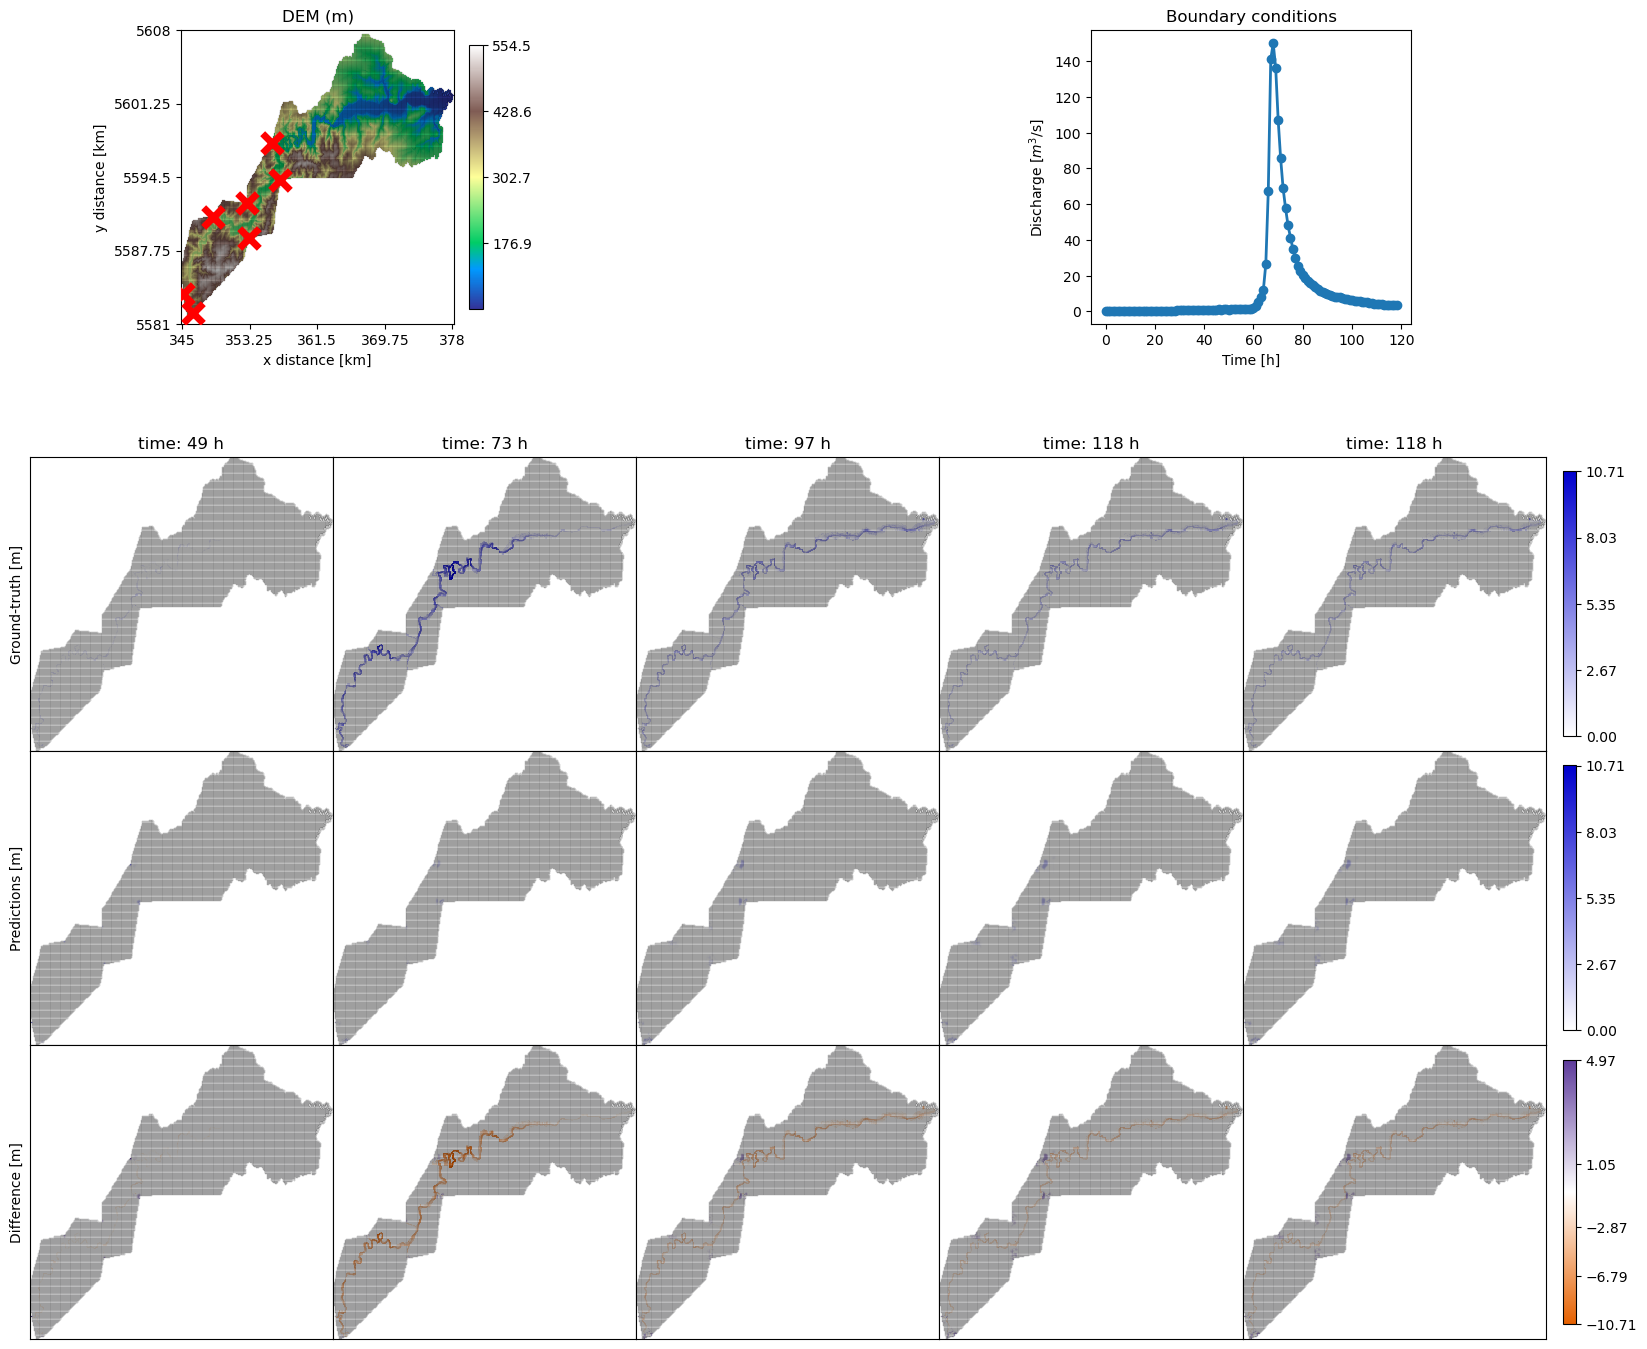

In [15]:
from utils.visualization import PlotRollout

model, hid, K_list = load_model_from_checkpoint(
    'results/best_sweep_coldstart.h5', dataset_cache['config_best_sweep_coldstart.yaml'][0],
    num_node_features=dataset_cache['config_best_sweep_coldstart.yaml'][4],
    num_edge_features=dataset_cache['config_best_sweep_coldstart.yaml'][5],
    previous_t=dataset_cache['config_best_sweep_coldstart.yaml'][3]['previous_t'],
    num_scales=dataset_cache['config_best_sweep_coldstart.yaml'][1][0].mesh.num_meshes, device='cpu',
)
cfg = dataset_cache['config_best_sweep_coldstart.yaml'][0]
test_dataset = dataset_cache['config_best_sweep_coldstart.yaml'][1]
scalers = dataset_cache['config_best_sweep_coldstart.yaml'][2]
temporal_params = dataset_cache['config_best_sweep_coldstart.yaml'][3]

plot_rollout = PlotRollout(
    model,
    test_dataset[0],
    scalers=scalers,
    warmup_steps=0,
    **temporal_params,
)
n_steps = plot_rollout.real_rollout.shape[-1]
plot_times = [48, 72, 96, n_steps - 1]
plot_rollout.compare_h_rollout(plot_times=plot_times, scale=0)
plt.show()